# Model Evaluation

This notebook evaluates the NBA player points prediction models trained in the project.

The analysis covers:
- model performance comparison
- prediction error analysis
- player-level error breakdown
- residual diagnostics
- feature importance using permutation importance

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.inspection import permutation_importance
import seaborn as sns

## Load evaluation files

Here I load:
- model-level evaluation metrics
- test set predictions generated by the training pipeline

In [195]:
results = pd.read_csv("../models/model_results.csv")
preds = pd.read_csv("../models/test_predictions.csv")

results

,model,mae,rmse,r2
0,baseline_last5,4.986899,6.542294,0.465517
1,linear_regression,4.780820,6.212447,0.518053
2,random_forest,4.813765,6.254456,0.511513


## Compare models by MAE

Mean Absolute Error (MAE) shows the average absolute prediction error in points.
Lower values indicate better model performance.

In [196]:
results.sort_values("mae")

,model,mae,rmse,r2
1,linear_regression,4.780820,6.212447,0.518053
2,random_forest,4.813765,6.254456,0.511513
0,baseline_last5,4.986899,6.542294,0.465517


## MAE comparison chart

This chart compares the average prediction error of all models.

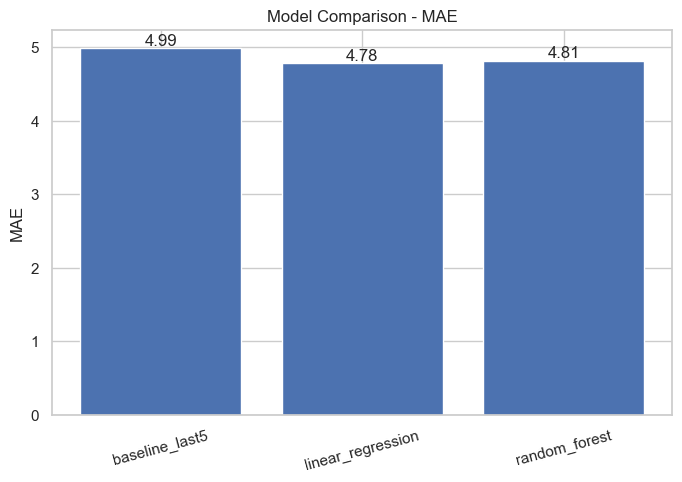

In [197]:
plt.figure(figsize=(8, 5))

bars = plt.bar(results["model"], results["mae"])

plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=15)

plt.bar_label(bars, fmt="%.2f")

plt.show()

## RMSE comparison chart

Root Mean Squared Error (RMSE) penalizes larger prediction errors more strongly than MAE.
It is useful for checking whether the model struggles with extreme scoring outcomes.

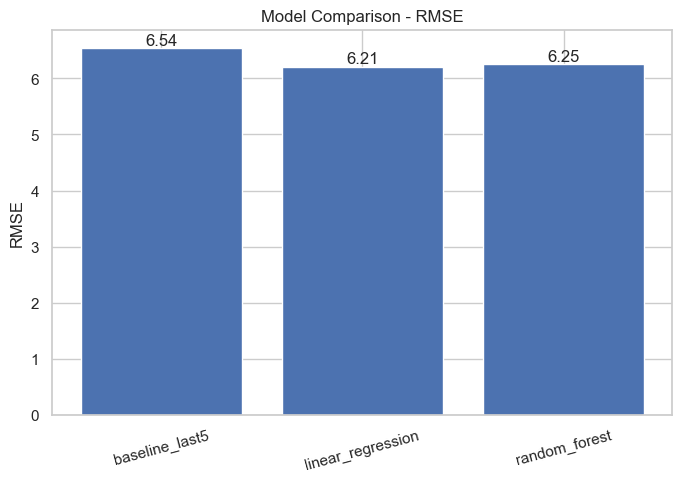

In [198]:
plt.figure(figsize=(8, 5))

bars = plt.bar(results["model"], results["rmse"])

plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

plt.bar_label(bars, fmt="%.2f")

plt.show()

## Predicted vs actual points

This scatter plot compares actual player points with Random Forest predictions.

The red dashed line represents perfect predictions:
- points on the line = exact predictions
- points below the line = model underestimates
- points above the line = model overestimates

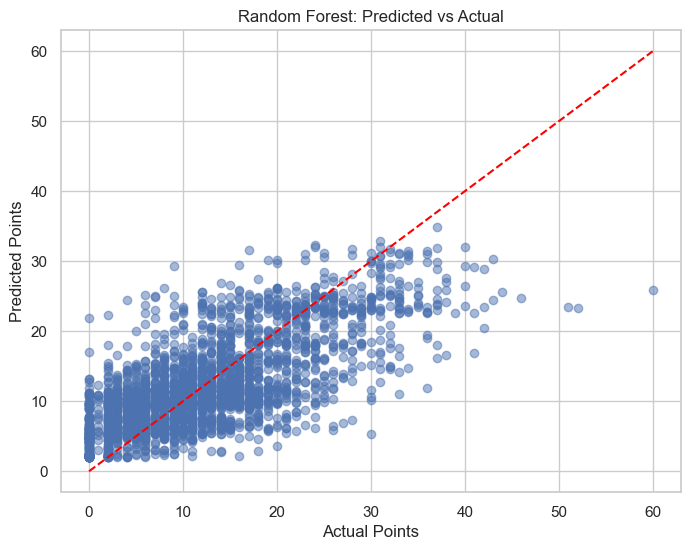

In [199]:
plt.figure(figsize=(8, 6))
plt.scatter(preds["PTS"], preds["rf_pred"], alpha=0.5)
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Random Forest: Predicted vs Actual")
plt.plot(
    [preds["PTS"].min(), preds["PTS"].max()],
    [preds["PTS"].min(), preds["PTS"].max()],
    linestyle="--",
    color="red"
)
plt.show()

## Prediction error distribution

This histogram shows how prediction errors are distributed.

Error is defined as:

actual points - predicted points

Interpretation:
- error = 0 → perfect prediction
- positive error → model underestimated points
- negative error → model overestimated points

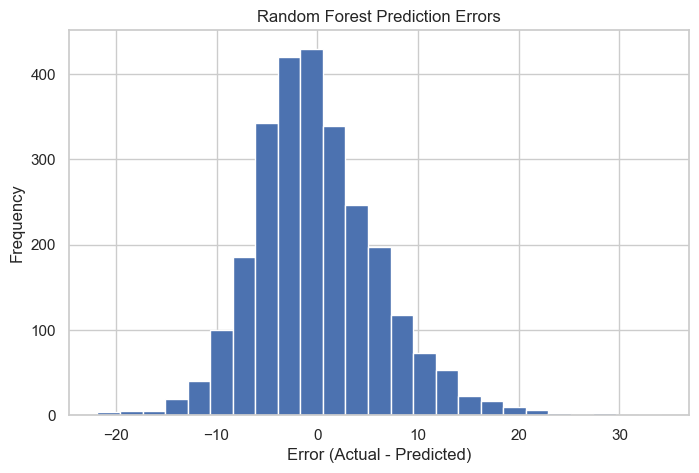

In [200]:
plt.figure(figsize=(8, 5))
plt.hist(preds["rf_error"], bins=25)
plt.title("Random Forest Prediction Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

## Player-level MAE

This table shows which players are hardest and easiest to predict.

For each player, I calculate the average absolute error of Random Forest predictions.

In [201]:
player_error = (
    preds.groupby("PLAYER_NAME")["rf_error"]
    .apply(lambda x: np.mean(np.abs(x)))
    .sort_values(ascending=False)
    .reset_index(name="mae_rf")
)

player_error.head(15)

,PLAYER_NAME,mae_rf
0,Stephen Curry,7.896971
1,Zach LaVine,7.712314
2,Tyrese Maxey,6.644292
3,Tim Hardaway Jr.,6.524263
4,Scotty Pippen Jr.,6.374330
5,Vít Krejčí,6.348307
6,Tobias Harris,6.342447
7,Tyrese Haliburton,6.313567
8,Paul George,6.035994
9,OG Anunoby,5.935562


## Best-predicted players

This table shows players with the lowest average error.

In [202]:
player_error.tail(10)

,PLAYER_NAME,mae_rf
47,Taylor Hendricks,3.695038
48,Svi Mykhailiuk,3.318765
49,Pat Connaughton,3.130959
50,Zeke Nnaji,2.971624
51,Orlando Robinson,2.955466
52,Walker Kessler,2.850416
53,Tosan Evbuomwan,2.398562
54,Sidy Cissoko,1.909122
55,Thanasis Antetokounmpo,1.811194
56,Wendell Moore Jr.,1.558420


## Residual plot

This chart shows prediction errors relative to predicted points.

Residual = actual - predicted

It helps identify:
- prediction bias
- underestimation of high-scoring games
- overestimation of low-scoring games

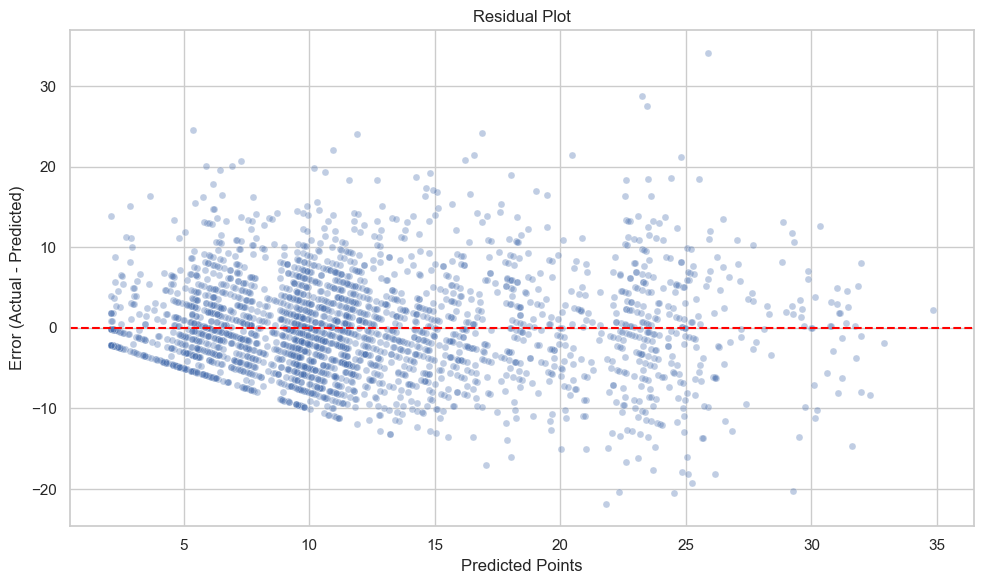

In [212]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=preds["rf_pred"],
    y=preds["rf_error"],
    alpha=0.35,
    s=25
)

plt.axhline(0, linestyle="--", color="red", linewidth=1.5)

plt.xlabel("Predicted Points")
plt.ylabel("Error (Actual - Predicted)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

## Error vs actual points

This chart helps check whether the model struggles more on very low-scoring or very high-scoring games.

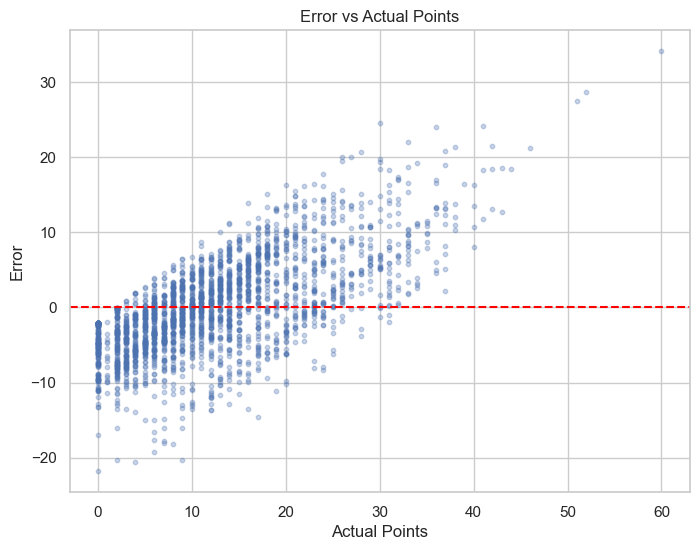

In [213]:
plt.figure(figsize=(8, 6))
plt.scatter(
    preds["PTS"],
    preds["rf_error"],
    alpha=0.3,
    s=10
)

plt.axhline(0, linestyle="--", color="red")

plt.xlabel("Actual Points")
plt.ylabel("Error")
plt.title("Error vs Actual Points")

plt.show()

## Prepare feature list for permutation importance

These are the input variables used by the Random Forest model.

In [214]:
feature_columns = [
    "HOME",
    "days_rest",
    "pts_last3",
    "pts_last5",
    "pts_last10",
    "min_last3",
    "min_last5",
    "fga_last3",
    "fga_last5",
    "fg3a_last5",
    "fta_last5",
    "reb_last5",
    "ast_last5",
    "pts_std_last5",
    "pts_trend",
    "min_trend",
    "fga_trend",
]

## Recreate test set for permutation importance

Here I rebuild the same test split used for evaluation, so I can measure how much model performance drops when each feature is shuffled.

In [215]:
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

## Load trained Random Forest model

In [216]:
with open("../models/random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

## Permutation importance

Permutation importance measures how much model performance decreases when one feature is randomly shuffled.

Higher values mean the model depends more on that feature.

In [217]:
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

## Permutation importance table

In [218]:
perm_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
4,pts_last10,2.513377,0.037504
8,fga_last5,0.251525,0.023078
5,min_last3,0.111046,0.006400
3,pts_last5,0.029094,0.004796
6,min_last5,0.022626,0.003853
12,ast_last5,0.015963,0.003144
10,fta_last5,0.014854,0.003383
13,pts_std_last5,0.012651,0.005836
7,fga_last3,0.012287,0.007166
2,pts_last3,0.009009,0.001405


## Permutation importance chart

This chart shows which features the Random Forest model relies on the most.

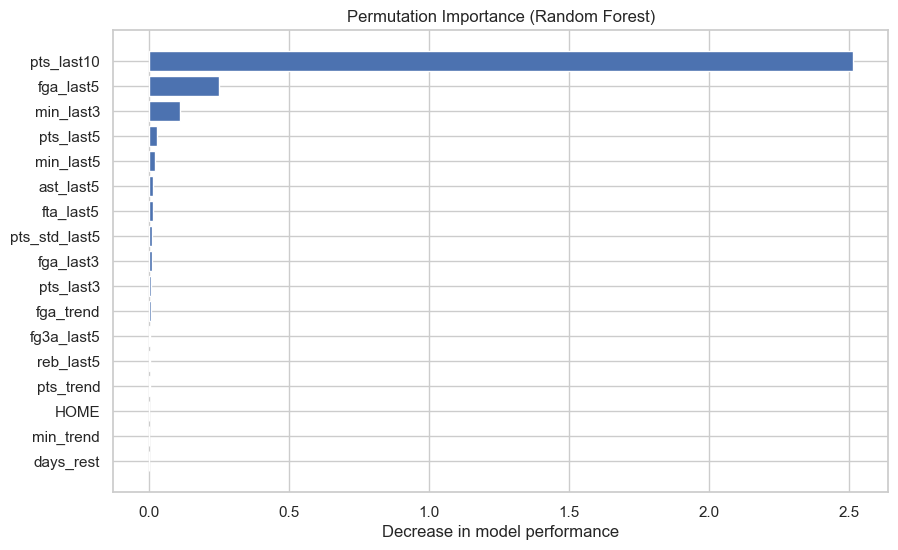

In [219]:
plt.figure(figsize=(10, 6))
plt.barh(perm_df["feature"], perm_df["importance_mean"])
plt.title("Permutation Importance (Random Forest)")
plt.xlabel("Decrease in model performance")
plt.gca().invert_yaxis()
plt.show()

## Final observations

Main takeaways from this evaluation:

- the model performs better than the baseline, but only moderately
- recent scoring average (`pts_last10`) is by far the most important feature
- the model tends to regress predictions toward the mean
- extreme high-scoring games are still difficult to predict
- additional contextual features should improve model quality in future iterations